#### MDTF MCS–Precipitation–Buoyancy Diagnostics: Generating Observational References

This notebook prepares observational reference datasets for the MDTF MCS–precipitation–buoyancy diagnostics.

- Default observational inputs include IMERG precipitation and NCEP/CPC brightness temperature.
- High-frequency precipitation data can be temporally aggregated, for example from hourly to 3-hourly, to match model output frequency.
- Observational precipitation and brightness temperature fields are remapped to a user-specified grid spacing for comparison with coarser-resolution model outputs.
- The workflow generates compact statistical output files for diagnostic plotting and model evaluation.
- See the `.rst` documentation file under `/doc/` for additional details.

In [6]:
import os
import sys
from pathlib import Path
import subprocess 
import xarray as xr

In [2]:
# assign the main directory to execute the scripts and to save the outputs
main_dir = Path("/global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg")
main_dir.exists()

True

In [3]:
# here we use a single year as an example for demonstration. 
year = 2001 

### Step 1. Identify 2-D MCS Masks

This step generates 2-D MCS mask files from precipitation and radiative/Tb inputs.

Main processing includes:

- Conservative remapping of precipitation to the target grid.
- Temporal aggregation of high-frequency precipitation, for example from 1-hourly means to 3-hourly means.
- Conversion from OLR to brightness temperature (Tb) when the input radiative variable in `rad_dir` is OLR. If the input is already Tb, this conversion can be skipped.

#### Input directory structure

Example:

`main_dir/your_data/${year}/{individual_monthly_files}`

We recommend concatenating high-frequency data into monthly files before running this step. This avoids excessive I/O from opening many small files.

#### Key parameters

- `year`: year to process.
- `work_dir`: main working directory where outputs will be generated.
- `pr_dir`: directory containing precipitation data.
- `rad_dir`: directory containing OLR or Tb data.
- `--pr-scale`: scaling factor used to convert precipitation to `mm/hr`.
- `--pr-agg-hr`: temporal aggregation window in hours.
- `--remap-grid-deg`: target grid spacing for remapping.
- `--output-stream`: source type, for example `obs` or `model` as a reminder.

#### Check available arguments

To check the full list of available arguments, run the following command in a notebook code cell:

`!python process_PyFLEXRKR_MCSmask_writeout_parallel.py --help`

In [4]:
from pathlib import Path
import subprocess
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed

main_dir = Path("/global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg")
script = main_dir / "process_PyFLEXRKR_MCSmask_writeout_parallel.py"
year = 2001

pr_dir = main_dir / "imerg_v7" / str(year)
rad_dir = main_dir / "imerg_v7" / str(year)

log_dir = main_dir / "logs"
log_dir.mkdir(parents=True, exist_ok=True)

# define the multiprocessing function. To avoid substantial memory loading (e.g., hourly, 0.1-deg IMERG), here we 
# use lazy loading to extract a tiny slice of data 
def run_one_month(month):
    log_file = log_dir / f"step1_MCSmask_{year}_{month:02d}.LOG.txt"

    cmd = [
        sys.executable,
        str(script),
        "--year", str(year),
        "--work_dir", str(main_dir),
        "--pr_dir", str(pr_dir),
        "--rad_dir", str(rad_dir),
        "--months", str(month),
        "--pr-var", "precipitation",
        "--rad-var", "tb",
        "--pr-scale", "1",
        "--pr-agg-hr", "3",
        "--remap-grid-deg", "0.25",
        "--target-lat-min", "-30",
        "--target-lat-max", "30",
        "--output-stream", "obs",
        "--scheduler", "single-threaded",
        "--num-workers", "4",
        "--month-workers", "1",
        "--chunks-time", "3",
    ]

    with open(log_file, "w") as f:
        result = subprocess.run(
            cmd,
            stdout=f,
            stderr=subprocess.STDOUT,
            text=True,
        )

    if result.returncode != 0:
        tail = log_file.read_text()[-4000:]
        raise RuntimeError(
            f"Month {month:02d} failed with code {result.returncode}.\n"
            f"Log: {log_file}\n\n{tail}"
        )

    return month, log_file

# run 4 months simultaneously (16 threads in total, max_paralle_months x num_workers)
months = list(range(1, 13))
max_parallel_months = 4

with ProcessPoolExecutor(max_workers=max_parallel_months) as executor:
    futures = {
        executor.submit(run_one_month, month): month
        for month in months
    }

    for future in as_completed(futures):
        month, log_file = future.result()
        print(f"Finished month {month:02d}. Log saved to: {log_file}")

Finished month 02. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_02.LOG.txt
Finished month 04. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_04.LOG.txt
Finished month 03. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_03.LOG.txt
Finished month 01. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_01.LOG.txt
Finished month 05. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_05.LOG.txt
Finished month 06. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MCSmask_2001_06.LOG.txt
Finished month 07. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/MC

### Step 2. Calculate Buoyancy–Precipitation Statistics
- Note that this step requires the lower-tropospehre buoyancy data precomputed. We don't calculate it here due to heavy computation from ERA-5 3-D raw data.

This step reads the processed 2-D MCS cloud masks from Step 1 and combines them with preprocessed ERA5 buoyancy variables to calculate precipitation statistics in the CAPE–SUBSAT phase space.

Main processing includes:

- Reading preprocessed ERA5 buoyancy/thetae files.
- Reading remapped 2-D MCS mask files generated from Step 1.
- Reading ERA5 precipitation files, for example `mtpr`, for reliability checks.
- Separating samples into MCS, deep non-MCS, and other regimes.
- Separating statistics over land and ocean using a land-sea mask.
- Subsampling the hourly data, for example to 6-hourly samples.
- Writing yearly 2-D histogram statistics for each regime.

#### Key inputs

- `--year`: year to process.
- `--working_dir`: main working directory where output statistics are written.
- `--buoy_dir`: directory containing preprocessed ERA5 buoyancy/thetae files.
- `--cloudmask_dir`: directory containing the 2-D MCS mask files generated in Step 1.
- `--landsea_file`: static ERA5 land-sea mask file.
- `--mpr-dir`: directory containing ERA5 precipitation files, for example monthly `mtpr` files.
- `--subsample-freq`: temporal subsampling frequency, for example `6h`.
- `--regrid-res`: output grid spacing for the statistics calculation.
- `--num-workers`: number of multiprocessing workers.

#### Output

The script writes yearly CAPE–SUBSAT histogram files under the statistics output directory, typically:

`obs/netCDF/stats/`

The output files contain statistics such as sample counts, precipitation sums, and reliable sample counts for different convective regimes and surface types.

#### Check available arguments

To check the full list of available arguments, run the following command in a notebook code cell or terminal:

`python process_BLcapesubsat_regions_unified.multiprocess.py --help`

In [7]:
script = main_dir / "process_BLcapesubsat.py"
buoy_dir = main_dir / "layer_thetae" / str(year)
cloudmask_dir = main_dir / "obs/netCDF/MCS_identifiers" / str(year)
landsea_file = main_dir / "ERA5_LandSeaMask.nc4"
mpr_dir = main_dir / "era5_mpr" / str(year)

log_dir = main_dir / "logs"
log_dir.mkdir(parents=True, exist_ok=True)
log_file = log_dir / f"step2_BLcapesubsat_{year}.txt"

cmd = [
    sys.executable,
    str(script),
    "--year", str(year),
    "--working_dir", str(main_dir),
    "--buoy_dir", str(buoy_dir),
    "--cloudmask_dir", str(cloudmask_dir),
    "--landsea_file", str(landsea_file),
    "--mpr-dir", str(mpr_dir),
    "--subsample-freq", "6h",
    "--regrid-res", "0.25",
    "--num-workers", "6",
]

print("Running command:")
print(" ".join(cmd))
print(f"Log file: {log_file}")

with open(log_file, "w") as f:
    result = subprocess.run(
        cmd,
        stdout=f,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    print(f"Script failed with return code {result.returncode}")
    print("\nLast 4000 characters of log:")
    print(log_file.read_text()[-4000:])
    raise RuntimeError(f"Command failed. See log: {log_file}")

print(f"Finished successfully. Log saved to: {log_file}")

Running command:
/pscratch/sd/w/wmtsai/anaconda3/envs/featenv2/bin/python /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/process_BLcapesubsat.py --year 2001 --working_dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg --buoy_dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/layer_thetae/2001 --cloudmask_dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/obs/netCDF/MCS_identifiers/2001 --landsea_file /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/ERA5_LandSeaMask.nc4 --mpr-dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/era5_mpr/2001 --subsample-freq 6h --regrid-res 0.25 --num-workers 6
Log file: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/step2_BLcapesubsat_2001.txt
Finished successfully. Log saved to: /global/cfs/cdirs

### Step 3. Calculate Monthly Precipitation and MCS Statistics

This step reads the remapped 2-D MCS cloud-mask files from Step 1 and calculates monthly precipitation and MCS occurrence statistics.

Main processing includes:

- Reading the remapped cloud-mask files generated in Step 1.
- Using the precipitation and MCS mask variables saved in each cloud-mask file.
- Calculating monthly precipitation frequency above a specified threshold.
- Calculating monthly accumulated MCS precipitation.
- Calculating monthly accumulated total precipitation.
- Calculating monthly MCS occurrence frequency.
- Writing yearly monthly statistics to NetCDF.

#### Key inputs

- `--year`: year to process.
- `--working_dir`: main working directory where output statistics are written.
- `--cloudmask_dir`: directory containing the remapped 2-D MCS mask files generated in Step 1.
- `--p-threshold`: precipitation threshold used to calculate precipitation frequency. For example, `0.01` means precipitation frequency is calculated as the fraction of valid samples with precipitation greater than `0.01 mm/hr`.

#### Output

The script writes yearly monthly precipitation and MCS statistics under the statistics output directory, typically:

`obs/netCDF/stats/`

The output file contains variables such as:

- `pr_freq`: monthly precipitation frequency above the specified threshold.
- `pr_mcssum`: monthly accumulated precipitation within MCS masks.
- `pr_totsum`: monthly accumulated total precipitation.
- `mcs_freq`: monthly MCS occurrence frequency.
- `tpr`: monthly mean precipitation rate.
- `effective_times`: number of valid samples used in each monthly calculation.

#### Check available arguments

To check the full list of available arguments, run the following command in a notebook code cell or terminal:

`python process_prmcs_stats_writeout.py --help`

In [8]:
script = main_dir / "process_prmcs_stats_writeout.py"

cloudmask_dir = main_dir / "obs/netCDF/MCS_identifiers" / str(year)

log_dir = main_dir / "logs"
log_dir.mkdir(parents=True, exist_ok=True)
log_file = log_dir / f"step3_prmcs_stats_{year}.txt"

cmd = [
    sys.executable,
    str(script),
    "--year", str(year),
    "--working_dir", str(main_dir),
    "--cloudmask_dir", str(cloudmask_dir),
    "--p-threshold", "0.01",
]

print("Running command:")
print(" ".join(cmd))
print(f"Log file: {log_file}")

with open(log_file, "w") as f:
    result = subprocess.run(
        cmd,
        stdout=f,
        stderr=subprocess.STDOUT,
        text=True,
    )

if result.returncode != 0:
    print(f"Script failed with return code {result.returncode}")
    print("\nLast 4000 characters of log:")
    print(log_file.read_text()[-4000:])
    raise RuntimeError(f"Command failed. See log: {log_file}")

print(f"Finished successfully. Log saved to: {log_file}")

Running command:
/pscratch/sd/w/wmtsai/anaconda3/envs/featenv2/bin/python /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/process_prmcs_stats_writeout.py --year 2001 --working_dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg --cloudmask_dir /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/obs/netCDF/MCS_identifiers/2001 --p-threshold 0.01
Log file: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/step3_prmcs_stats_2001.txt
Finished successfully. Log saved to: /global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/logs/step3_prmcs_stats_2001.txt


In [9]:
ds = xr.open_dataset('/global/cfs/cdirs/m4374/user_work_directories/wmtsai/HighResModel_data/obs_gpmimerg/obs/netCDF/stats/precip_mcsstats_monthly.2001.0.25deg.nc')

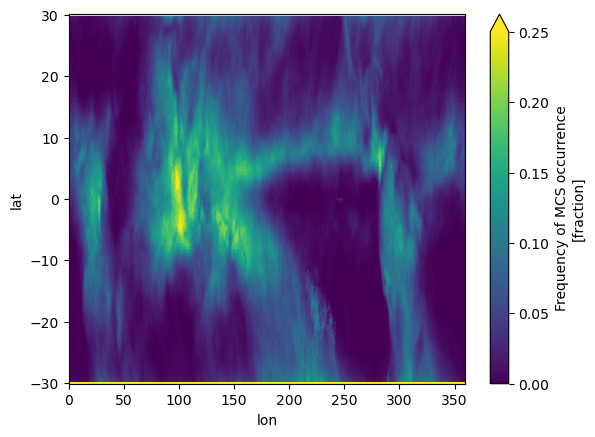

In [10]:
ds.mcs_freq.mean(('year','month')).plot(vmin=0, vmax=0.25)